In [1]:
%pip install noise numpy matplotlib

  Using cached noise-1.2.2-cp313-cp313-linux_x86_64.whl
  Using cached numpy-2.3.2-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached matplotlib-3.10.5-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.59.1-cp313-cp313-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (108 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-11.3.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached numpy-2.3.2-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached matplotlib-3.10.5-cp

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from noise import pnoise3
import math
import hashlib

# Utility: draw filled disk into canvas
def draw_disk(canvas, x, y, radius=2):
    h, w = canvas.shape
    xi = int(round(x))
    yi = int(round(y))
    rx = range(max(0, xi-radius), min(w, xi+radius+1))
    ry = range(max(0, yi-radius), min(h, yi+radius+1))
    rr = radius*radius
    for nx in rx:
        for ny in ry:
            dx = nx - x
            dy = ny - y
            if dx*dx + dy*dy <= rr:
                canvas[ny, nx] = 255

# Quantized angle sampling using Perlin (noise.pnoise3)
def quantized_angle(x, y, scale, grid_angles, noise_strength, seed):
    # pnoise3 returns in [-1,1] for typical usage; keep it deterministic via seed offset
    val = pnoise3(x*scale, y*scale, seed) * noise_strength
    # clamp to [-1,1] then map to [0,1] range for more stable rounding
    val = max(-1.0, min(1.0, val))
    base = round(val * grid_angles) * (2.0 * math.pi / grid_angles)
    return base

def generate_perlin_roads(canvas_size=1000, num_worms=100, worm_length=500, step_size=1.0, perlin_scale=0.01, seed=2, grid_angles=4, noise_strength=1.0, road_width=3):
    rng = np.random.default_rng(seed)
    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    for i in range(num_worms):
        x = rng.uniform(0, canvas_size)
        y = rng.uniform(0, canvas_size)
        for j in range(worm_length):
            draw_disk(canvas, x, y, radius=road_width)
            angle = quantized_angle(x, y, perlin_scale, grid_angles, noise_strength, seed)
            x += math.cos(angle) * step_size
            y += math.sin(angle) * step_size
    return canvas

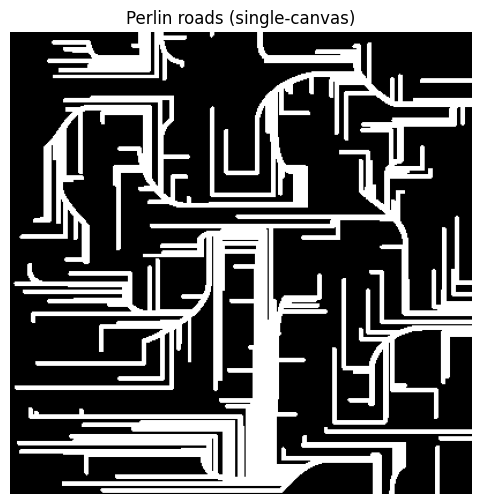

In [3]:
# Quick demo: generate and show a small canvas (reduced sizes for notebook responsiveness)
canvas = generate_perlin_roads(canvas_size=400, num_worms=200, worm_length=800, step_size=1.0, perlin_scale=0.01, seed=42, grid_angles=4, noise_strength=1.0, road_width=2)
plt.figure(figsize=(6,6))
plt.imshow(canvas, cmap='gray', origin='lower')
plt.title('Perlin roads (single-canvas)')
plt.axis('off')
plt.show()

## Chunk-aware generation

We implement a chunk-aware generator which: uses global/world coordinates for Perlin sampling, places deterministic worm starts via a spatial hash, and generates with padding so roads crossing borders appear in adjacent chunks.

In [4]:
def spatial_hash(seed, i, j, k=0):
    # deterministic float in [0,1) from integer inputs
    m = hashlib.sha256()
    m.update(f'{seed}:{i}:{j}:{k}'.encode('utf-8'))
    h = m.digest()
    # take first 8 bytes as uint64
    v = int.from_bytes(h[:8], 'little')
    return (v & ((1<<53)-1)) / float(1<<53)

def generate_chunk(chunk_x, chunk_y, chunk_size=256, padding=64, num_worms=200, worm_length=800, step_size=1.0, perlin_scale=0.01, seed=2, grid_angles=4, noise_strength=1.0, road_width=3):
    # world region to generate (with padding)
    wx = chunk_x * chunk_size - padding
    wy = chunk_y * chunk_size - padding
    size = chunk_size + 2*padding
    canvas = np.zeros((size, size), dtype=np.uint8)
    # Choose a fixed global grid spacing (cells that hold deterministic start offsets)
    cell_spacing = max(16, padding // 2)
    gx_min = math.floor(wx / cell_spacing)
    gx_max = math.floor((wx + size) / cell_spacing)
    gy_min = math.floor(wy / cell_spacing)
    gy_max = math.floor((wy + size) / cell_spacing)
    count = 0
    for gx in range(gx_min, gx_max + 1):
        for gy in range(gy_min, gy_max + 1):
            if count >= num_worms:
                break
            # derive a deterministic offset inside the grid cell from the global indices
            u = spatial_hash(seed, gx, gy, 0)
            v = spatial_hash(seed, gx, gy, 1)
            x = gx * cell_spacing + u * cell_spacing
            y = gy * cell_spacing + v * cell_spacing
            for j in range(worm_length):
                lx = x - wx
                ly = y - wy
                if 0 <= lx < size and 0 <= ly < size:
                    draw_disk(canvas, lx, ly, radius=road_width)
                angle = quantized_angle(x, y, perlin_scale, grid_angles, noise_strength, seed)
                x += math.cos(angle) * step_size
                y += math.sin(angle) * step_size
            count += 1
    # crop to chunk region
    sx = padding
    sy = padding
    cropped = canvas[sy:sy+chunk_size, sx:sx+chunk_size].copy()
    return cropped

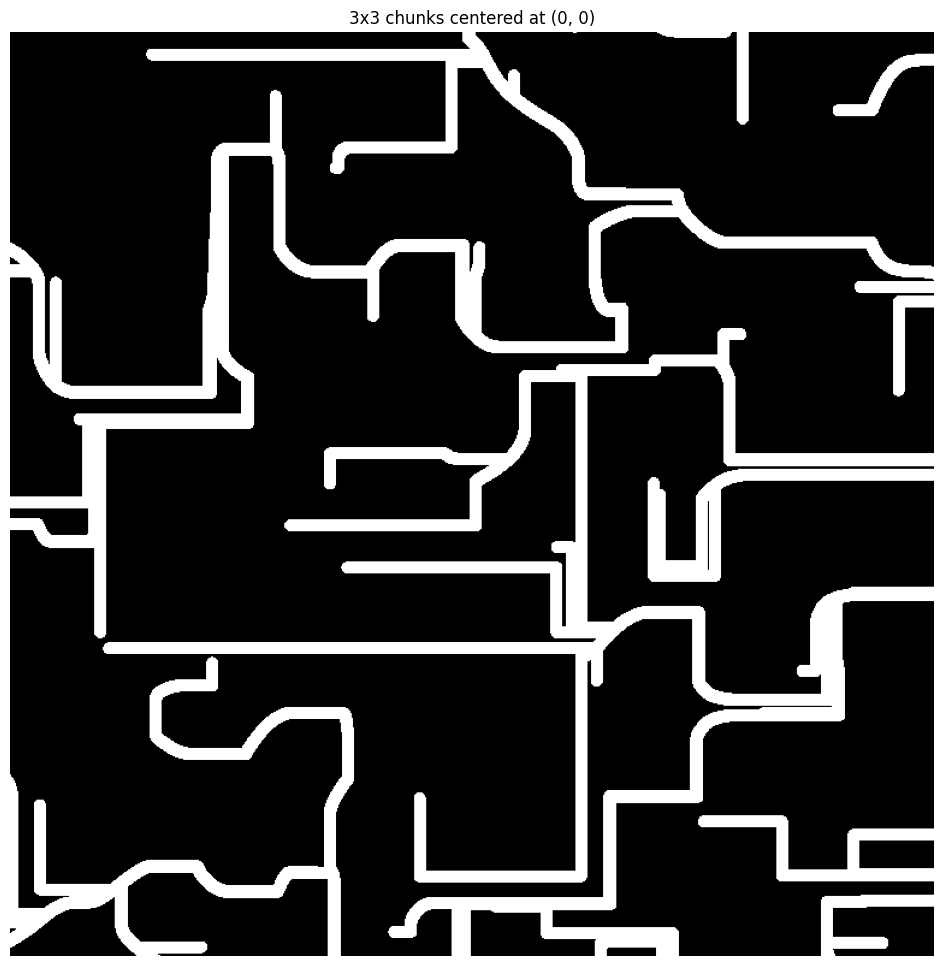

In [5]:
# Generate a square grid of chunks centered on a given chunk coordinate
# Specify the center chunk coordinates (world chunk indices) and a radius (half-size).
# radius=2 -> 5x5 grid
center_x, center_y = 0, 0  # change these to any world chunk coordinates
radius = 1
rows = []
for gy in range(center_y - radius, center_y + radius + 1):
    row_chunks = []
    for gx in range(center_x - radius, center_x + radius + 1):
        # generate each chunk at global chunk coordinates (gx, gy)
        c = generate_chunk(gx, gy, chunk_size=256, padding=256, num_worms=100, worm_length=1000, seed=42, grid_angles=4, perlin_scale=0.01, road_width=5)
        row_chunks.append(c)
    # concatenate chunks horizontally for this row
    rows.append(np.hstack(row_chunks))
# stack all rows vertically to form the full grid
stitched = np.vstack(rows)
plt.figure(figsize=(12,12))
plt.imshow(stitched, cmap='gray', origin='lower')
plt.title(f'{(2*radius+1)}x{(2*radius+1)} chunks centered at ({center_x}, {center_y})')
plt.axis('off')
plt.show()

Notes:
- This implementation uses global-coordinate Perlin sampling and deterministic worm starts via `spatial_hash`.
- Padding allows worms that start outside a chunk to paint into it, avoiding visible seams.
- Parameters (padding, num_worms, worm_length) trade memory and quality; tune per your needs.